# Image Augmentation

In this notebook, I'll train CIFAR10 on a simple CNN (a) without image augmentation (b) with image augmentation using a single transform (RandomHorizontalFlip), and (c) with image augmentation using multiple transforms (RandomHorizontalFlip, RandomResizedCrop, ColorJitter).

In [1]:
import sys
import os
sys.path.append(os.getcwd() + "/..")

import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

from utils.models import Module
from utils.train import train_model
from utils.data import WrappedDataLoader

In [2]:
print(torch.cuda.is_available())

True


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


Hyperparameters

In [4]:
resize = (32, 32)
datadir = os.getcwd() + '/datasets'
batch_size = 256
lr = 5e-4
num_epochs = 20

Create model

In [5]:
class ConvCifar10(Module): 
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), 
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), 
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), 
            nn.ReLU(),
            nn.LazyLinear(84), 
            nn.ReLU(),
            nn.LazyLinear(num_classes)
        )
    
    def forward(self, x):
        return self.net(x)
    
class ResNet18(Module):
    def __init__(self):
        super().__init__()
        self.net = models.resnet18()
    
    def forward(self, x):
        return self.net(x)

In [6]:
def get_model():
    return ResNet18().to(device)
    #return ConvCifar10()

In [7]:
def put_batch(*batch):
    return tuple(arr.to(device) for arr in batch)

## CIFAR10 without image augmentation

In [8]:
train_transform = transforms.Compose([transforms.ToTensor(), transforms.Resize(resize)])
val_transform = transforms.Compose([transforms.ToTensor(), transforms.Resize(resize)])

In [9]:
train_ds = datasets.CIFAR10(root=datadir, transform=train_transform, train=True, download=True)
val_ds = datasets.CIFAR10(root=datadir, transform=val_transform, train=False, download=True)

train_dl = WrappedDataLoader(DataLoader(train_ds, batch_size=batch_size, shuffle=True), put_batch)
val_dl = WrappedDataLoader(DataLoader(val_ds, batch_size=batch_size), put_batch)

Plot images

In [10]:
num_cols = 4
num_rows = 4
assert batch_size >= num_cols * num_rows

torch.Size([256, 3, 32, 32])
torch.Size([256])


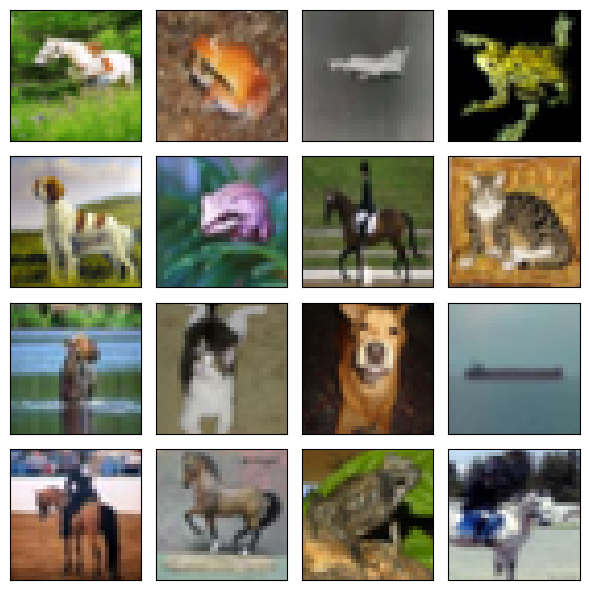

In [11]:
for X, y in train_dl:
    print(X.shape)
    print(y.shape)
    break

fig, axs = plt.subplots(num_rows, num_cols, figsize=(6,6))

for i in range(num_rows):
    for j in range(num_cols):
        idx = i * num_rows + j
        axs[i, j].imshow(torch.permute(X[idx].to("cpu"), (1,2,0)))
        #axs[i, j].tick_params(length=0)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
fig.tight_layout()
plt.show()

Setup model, optimizer, etc

In [12]:
model = get_model()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
X_test = torch.randn(batch_size, 3, 32, 32).to(device)
model(X_test);

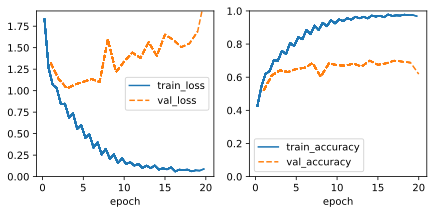

In [13]:
train_model(model, train_dl, val_dl, optimizer, num_epochs)
plt.show()

## Image Augmentation using RandomHorizontalFlip

In [14]:
train_transform = transforms.Compose([transforms.ToTensor(), transforms.Resize(resize), transforms.RandomHorizontalFlip()])
val_transform = transforms.Compose([transforms.ToTensor(), transforms.Resize(resize)])

In [15]:
train_ds = datasets.CIFAR10(root=datadir, transform=train_transform, train=True, download=True)
val_ds = datasets.CIFAR10(root=datadir, transform=val_transform, train=False, download=True)

train_dl = WrappedDataLoader(DataLoader(train_ds, batch_size=batch_size, shuffle=True), put_batch)
val_dl = WrappedDataLoader(DataLoader(val_ds, batch_size=batch_size), put_batch)

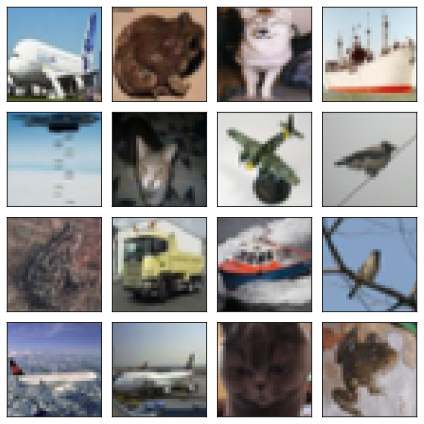

In [16]:
for X, y in train_dl:
    break

fig, axs = plt.subplots(num_rows, num_cols, figsize=(6,6))

for i in range(num_rows):
    for j in range(num_cols):
        idx = i * num_rows + j
        axs[i, j].imshow(torch.permute(X[idx].to("cpu"), (1,2,0)))
        #axs[i, j].tick_params(length=0)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
fig.tight_layout()
plt.show()

In [17]:
model = get_model()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
X_test = torch.randn(batch_size, 3, 32, 32).to(device)
model(X_test);

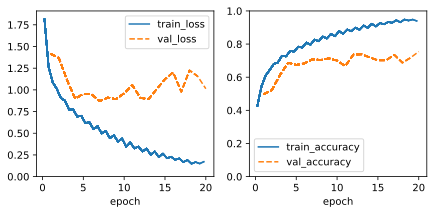

In [18]:
train_model(model, train_dl, val_dl, optimizer, num_epochs)
plt.show()

## Image Augmentation using Multiple Transforms (RandomHorizontalFlip, RandomCrop, ColorJitter)

In [19]:
train_transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.RandomCrop(resize, padding=4), 
    transforms.RandomHorizontalFlip(), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomErasing()])
val_transform = transforms.Compose([
    transforms.ToTensor(), transforms.Resize(resize)])

In [20]:
train_ds = datasets.CIFAR10(root=datadir, transform=train_transform, train=True, download=True)
val_ds = datasets.CIFAR10(root=datadir, transform=val_transform, train=False, download=True)

train_dl = WrappedDataLoader(DataLoader(train_ds, batch_size=batch_size, shuffle=True), put_batch)
val_dl = WrappedDataLoader(DataLoader(val_ds, batch_size=batch_size), put_batch)

torch.Size([256, 3, 32, 32])
torch.Size([256])


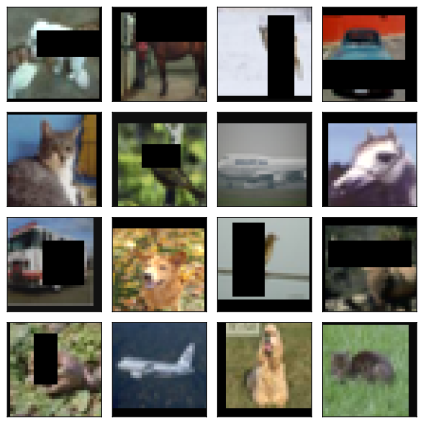

In [21]:
for X, y in train_dl:
    print(X.shape)
    print(y.shape)
    break

fig, axs = plt.subplots(num_rows, num_cols, figsize=(6,6))

for i in range(num_rows):
    for j in range(num_cols):
        idx = i * num_rows + j
        axs[i, j].imshow(torch.permute(X[idx].to("cpu"), (1,2,0)))
        #axs[i, j].tick_params(length=0)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
fig.tight_layout()
plt.show()

In [22]:
model = get_model()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
X_test = torch.randn(batch_size, 3, 32, 32).to(device)
model(X_test);

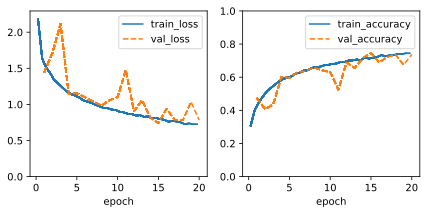

In [23]:
train_model(model, train_dl, val_dl, optimizer, num_epochs);